# UNLE and LightNet Methods Comparison

This notebook compares two near-field photometric stereo methods:
1. **Uncalibrated Near-Field (UNF/UNLE)**: Estimates light positions, intensities, normals, and depth
2. **LightNet (ML-based)**: Estimates light positions using a trained neural network

Metrics include:
- Angular normal error
- Depth RMSE
- Albedo MSE
- Light position Euclidean/angular error


In [2]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image
import torch

# Add src to path
sys.path.insert(0, str(Path.cwd() / 'src'))

from dataset import generate_dataset
from unle import UNLPSEngine
from UNLE.geometry_util import GeometryUtils
from UNLE.lightnet import LightNet
from util import load_dataset


## 1. Configuration and Dataset Loading


In [ ]:
# Configuration
MODEL_NAME = "buddha"  # Change to "bunny" or path to custom mesh

# Paths
PROJECT_DIR = Path.cwd()
DATASET_DIR = PROJECT_DIR / "dataset" / MODEL_NAME
RESULTS_DIR = PROJECT_DIR / "results" / MODEL_NAME

print(f"Dataset directory: {DATASET_DIR}")
print(f"Results directory: {RESULTS_DIR}")

# Load dataset
dataset = load_dataset(str(DATASET_DIR))

print(f"\nDataset loaded!")
print(f"Dataset shape: {dataset.shape}")
print(f"Number of images: {len(dataset)}")
print(f"Image resolution: {dataset.shape[1]}x{dataset.shape[2]}")

# Get RGB images
rgb_images = dataset.rgb()
print(f"RGB images shape: {rgb_images.shape}")

# Get camera intrinsics
cam = dataset.metadata["camera"]
intrinsics = {
    "fx": cam["fx"],
    "fy": cam["fy"],
    "cx": cam["cx"],
    "cy": cam["cy"],
}


K=100
# indices = np.random.choice(rgb_images.shape[0], K, replace=False)
rgb_images = rgb_images[:100]
num_lights = K


## 2. Run UNLE (Uncalibrated Near-Field)

Estimate light positions, intensities, normals, depth, and albedo using the UNLE method.


In [ ]:
print("Running uncalibrated near-field photometric stereo (UNLE)...")

# Convert RGB to grayscale
weights = np.array([0.2126, 0.7152, 0.0722], dtype=rgb_images.dtype)
images_gray = np.tensordot(rgb_images, weights, axes=([3], [0]))  # (K,H,W)

# Optional valid mask
valid_mask_unle = None
try:
    vm_path = DATASET_DIR / "valid_mask.npy"
    if vm_path.exists():
        valid_mask_unle = np.load(vm_path).astype(bool)
        print(f"Loaded valid mask from {vm_path}")
except Exception as e:
    print(f"Could not load valid mask: {e}, using default mask")

import matplotlib.pyplot as plt
plt.imshow(valid_mask_unle*255.0, cmap='gray')
plt.show()


# Initialize and run UNLE
engine = UNLPSEngine(
    images_gray,
    intrinsics,
    valid_mask=valid_mask_unle,
    exponent_q=3,
    mean_depth_init=1.0,
    bounds=((-2.0, 2.0), (-2.0, 2.0), (-2.0, 2.0)),
    step=0.1
)

N_unle, A_unle, z_unle, L_unle, e_unle = engine.solve(
    max_iters=100,
    depth_tol=1e-4,
    gd_steps=100,
    gd_lr=0.001,
)


print("Uncalibrated near-field photometric stereo (UNLE) complete!")
print(f"Normals shape: {N_unle.shape}")
print(f"Albedos shape: {A_unle.shape}")
print(f"Depth shape: {z_unle.shape}")
print(f"Light positions shape: {L_unle.shape}")
print(f"Light intensities shape: {e_unle.shape}")


In [ ]:
from util import load_dataset, save_normals, save_normals_as_image, save_albedo, save_albedo_as_image
#save albedo and normals

save_normals(N_unle, str(RESULTS_DIR / "normals_unle.npy"))
save_normals_as_image(N_unle, str(RESULTS_DIR / "normals_unle.png"))
save_albedo(A_unle, str(RESULTS_DIR / "albedos_unle.npy"))
save_albedo_as_image(A_unle, str(RESULTS_DIR / "albedos_unle.png"))
np.save( str(RESULTS_DIR / "depth_unle.npy"), z_unle)


Dataset directory: /Users/wushengxi/Desktop/10701_light_estimation/dataset/dragon
Results directory: /Users/wushengxi/Desktop/10701_light_estimation/results/dragon
Loading dataset from /Users/wushengxi/Desktop/10701_light_estimation/dataset/dragon...

Dataset loaded!
Dataset shape: (200, 512, 512, 10)
Number of images: 200
Image resolution: 512x512
RGB images shape: (200, 512, 512, 3)
Running uncalibrated near-field photometric stereo (UNLE)...
Loaded valid mask from /Users/wushengxi/Desktop/10701_light_estimation/dataset/dragon/valid_mask.npy


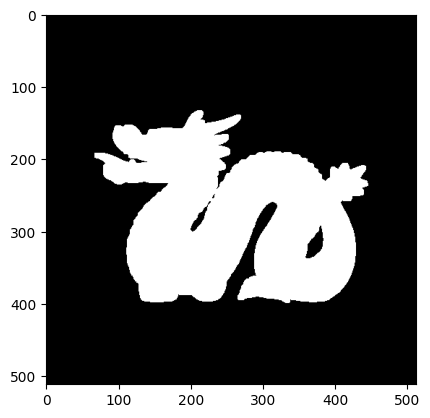

Coarse initialization of lights (classical UNLPS) ...


KeyboardInterrupt: 

In [6]:
# Configuration
MODEL_NAME = "dragon"  # Change to "bunny" or path to custom mesh

# Paths
PROJECT_DIR = Path.cwd()
DATASET_DIR = PROJECT_DIR / "dataset" / MODEL_NAME
RESULTS_DIR = PROJECT_DIR / "results" / MODEL_NAME

print(f"Dataset directory: {DATASET_DIR}")
print(f"Results directory: {RESULTS_DIR}")

# Load dataset
dataset = load_dataset(str(DATASET_DIR))

print(f"\nDataset loaded!")
print(f"Dataset shape: {dataset.shape}")
print(f"Number of images: {len(dataset)}")
print(f"Image resolution: {dataset.shape[1]}x{dataset.shape[2]}")

# Get RGB images
rgb_images = dataset.rgb()
print(f"RGB images shape: {rgb_images.shape}")

# Get camera intrinsics
cam = dataset.metadata["camera"]
intrinsics = {
    "fx": cam["fx"],
    "fy": cam["fy"],
    "cx": cam["cx"],
    "cy": cam["cy"],
}


K=100
# indices = np.random.choice(rgb_images.shape[0], K, replace=False)
rgb_images = rgb_images[:100]
num_lights = K

print("Running uncalibrated near-field photometric stereo (UNLE)...")

# Convert RGB to grayscale
weights = np.array([0.2126, 0.7152, 0.0722], dtype=rgb_images.dtype)
images_gray = np.tensordot(rgb_images, weights, axes=([3], [0]))  # (K,H,W)

# Optional valid mask
valid_mask_unle = None
try:
    vm_path = DATASET_DIR / "valid_mask.npy"
    if vm_path.exists():
        valid_mask_unle = np.load(vm_path).astype(bool)
        print(f"Loaded valid mask from {vm_path}")
except Exception as e:
    print(f"Could not load valid mask: {e}, using default mask")

import matplotlib.pyplot as plt
plt.imshow(valid_mask_unle*255.0, cmap='gray')
plt.show()


# Initialize and run UNLE
engine = UNLPSEngine(
    images_gray,
    intrinsics,
    valid_mask=valid_mask_unle,
    exponent_q=3,
    mean_depth_init=1.0,
    bounds=((-2.0, 2.0), (-2.0, 2.0), (0.0, 3.0)),
    step=0.2
)

N_unle, A_unle, z_unle, L_unle, e_unle = engine.solve(
    max_iters=100,
    depth_tol=1e-4,
    gd_steps=100,
    gd_lr=0.001,
)

print("Uncalibrated near-field photometric stereo (UNLE) complete!")
print(f"Normals shape: {N_unle.shape}")
print(f"Albedos shape: {A_unle.shape}")
print(f"Depth shape: {z_unle.shape}")
print(f"Light positions shape: {L_unle.shape}")
print(f"Light intensities shape: {e_unle.shape}")

from util import load_dataset, save_normals, save_normals_as_image, save_albedo, save_albedo_as_image
#save albedo and normals

save_normals(N_unle, str(RESULTS_DIR / "normals_unle.npy"))
save_normals_as_image(N_unle, str(RESULTS_DIR / "normals_unle.png"))
save_albedo(A_unle, str(RESULTS_DIR / "albedos_unle.npy"))
save_albedo_as_image(A_unle, str(RESULTS_DIR / "albedos_unle.png"))
np.save( str(RESULTS_DIR / "depth_unle.npy"), z_unle)


Dataset directory: /Users/wushengxi/Desktop/10701_light_estimation/dataset/bunny
Results directory: /Users/wushengxi/Desktop/10701_light_estimation/results/bunny
Loading dataset from /Users/wushengxi/Desktop/10701_light_estimation/dataset/bunny...

Dataset loaded!
Dataset shape: (200, 512, 512, 10)
Number of images: 200
Image resolution: 512x512
RGB images shape: (200, 512, 512, 3)
Running uncalibrated near-field photometric stereo (UNLE)...
Loaded valid mask from /Users/wushengxi/Desktop/10701_light_estimation/dataset/bunny/valid_mask.npy


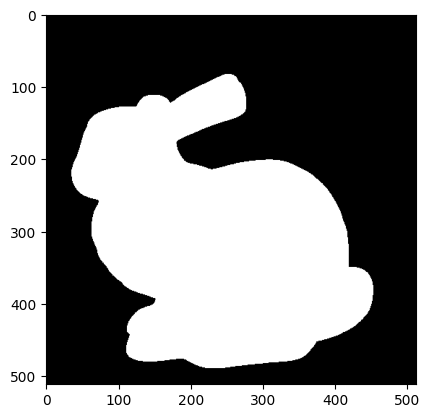

Coarse initialization of lights (classical UNLPS) ...
  Light 0: coarse L=[-0.03955606  0.29936144  2.        ], e=-0.010
  Light 1: coarse L=[-0.03955606  0.29936144  1.8       ], e=-0.007
  Light 2: coarse L=[-0.03955606  0.09936143  1.8       ], e=-0.007
  Light 3: coarse L=[-0.03955606  0.29936144  1.8       ], e=-0.007
  Light 4: coarse L=[-0.23955606  0.29936144  1.8       ], e=-0.007
  Light 5: coarse L=[0.16044395 0.09936143 2.        ], e=-0.010
  Light 6: coarse L=[-0.03955606  0.29936144  1.6       ], e=-0.004
  Light 7: coarse L=[-0.03955606  0.09936143  1.6       ], e=-0.004
  Light 8: coarse L=[0.36044395 0.29936144 2.2       ], e=-0.015
  Light 9: coarse L=[-0.23955606  0.29936144  1.6       ], e=-0.004
  Light 10: coarse L=[ 0.16044395 -0.10063857  2.        ], e=-0.010
  Light 11: coarse L=[-0.03955606  0.49936143  1.8       ], e=-0.007
  Light 12: coarse L=[-0.23955606  0.29936144  1.8       ], e=-0.006
  Light 13: coarse L=[ 0.56044394 -0.10063857  2.2       ], e=-0.

In [7]:
# Configuration
MODEL_NAME = "bunny"  # Change to "bunny" or path to custom mesh

# Paths
PROJECT_DIR = Path.cwd()
DATASET_DIR = PROJECT_DIR / "dataset" / MODEL_NAME
RESULTS_DIR = PROJECT_DIR / "results" / MODEL_NAME

print(f"Dataset directory: {DATASET_DIR}")
print(f"Results directory: {RESULTS_DIR}")

# Load dataset
dataset = load_dataset(str(DATASET_DIR))

print(f"\nDataset loaded!")
print(f"Dataset shape: {dataset.shape}")
print(f"Number of images: {len(dataset)}")
print(f"Image resolution: {dataset.shape[1]}x{dataset.shape[2]}")

# Get RGB images
rgb_images = dataset.rgb()
print(f"RGB images shape: {rgb_images.shape}")

# Get camera intrinsics
cam = dataset.metadata["camera"]
intrinsics = {
    "fx": cam["fx"],
    "fy": cam["fy"],
    "cx": cam["cx"],
    "cy": cam["cy"],
}


K=100
indices = np.random.choice(rgb_images.shape[0], K, replace=False)
rgb_images = rgb_images[indices]
num_lights = K

print("Running uncalibrated near-field photometric stereo (UNLE)...")

# Convert RGB to grayscale
weights = np.array([0.2126, 0.7152, 0.0722], dtype=rgb_images.dtype)
images_gray = np.tensordot(rgb_images, weights, axes=([3], [0]))  # (K,H,W)

# Optional valid mask
valid_mask_unle = None
try:
    vm_path = DATASET_DIR / "valid_mask.npy"
    if vm_path.exists():
        valid_mask_unle = np.load(vm_path).astype(bool)
        print(f"Loaded valid mask from {vm_path}")
except Exception as e:
    print(f"Could not load valid mask: {e}, using default mask")

import matplotlib.pyplot as plt
plt.imshow(valid_mask_unle*255.0, cmap='gray')
plt.show()


# Initialize and run UNLE
engine = UNLPSEngine(
    images_gray,
    intrinsics,
    valid_mask=valid_mask_unle,
    exponent_q=3,
    mean_depth_init=1.0,
    bounds=((-2.0, 2.0), (-2.0, 2.0), (0.0, 3.0)),
    step=0.2
)

N_unle, A_unle, z_unle, L_unle, e_unle = engine.solve(
    max_iters=100,
    depth_tol=1e-4,
    gd_steps=1000,
    gd_lr=0.001,
)

print("Uncalibrated near-field photometric stereo (UNLE) complete!")
print(f"Normals shape: {N_unle.shape}")
print(f"Albedos shape: {A_unle.shape}")
print(f"Depth shape: {z_unle.shape}")
print(f"Light positions shape: {L_unle.shape}")
print(f"Light intensities shape: {e_unle.shape}")

from util import load_dataset, save_normals, save_normals_as_image, save_albedo, save_albedo_as_image
#save albedo and normals

save_normals(N_unle, str(RESULTS_DIR / "normals_unle.npy"))
save_normals_as_image(N_unle, str(RESULTS_DIR / "normals_unle.png"))
save_albedo(A_unle, str(RESULTS_DIR / "albedos_unle.npy"))
save_albedo_as_image(A_unle, str(RESULTS_DIR / "albedos_unle.png"))
np.save( str(RESULTS_DIR / "depth_unle.npy"), z_unle)


## 3. Run LightNet (ML-based Light Estimation)

Estimate light positions using a trained LightNet model, which uses UNLE normals and albedo as input.


In [38]:
print("Loading and running LightNet for light position estimation...")

# Load the trained LightNet model
model_path = PROJECT_DIR / "experiments" / MODEL_NAME / "lr0.0001_b8_lam0.1_K200_512" / "lightnet.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

RES = 128   # target resolution
import cv2

# ----------------------------------------------------
# Resize ALL inputs to 128×128 before using the model
# ----------------------------------------------------

# 1. Resize images_gray[k] beforehand (if not already)
images_gray_128 = np.zeros((K, RES, RES), np.float32)
for k in range(K):
    images_gray_128[k] = cv2.resize(
        images_gray[k].astype(np.float32),
        (RES, RES),
        interpolation=cv2.INTER_AREA
    )

# 2. Resize Albedo
A_128 = cv2.resize(
    gt_albedos.astype(np.float32),
    (RES, RES),
    interpolation=cv2.INTER_AREA
)

# 3. Resize Normals channel-by-channel
N_128 = np.zeros((RES, RES, 3), np.float32)
for c in range(3):
    N_128[..., c] = cv2.resize(
        gt_albedos[..., c].astype(np.float32),
        (RES, RES),
        interpolation=cv2.INTER_CUBIC
    )

# ----------------------------------------------------
# Normalization (Albedo + Normals)
# ----------------------------------------------------
A_norm = A_128.copy()
if A_norm.max() > 0:
    A_norm = A_norm / (A_norm.max() + 1e-8)

N_norm = N_128.copy()
norms = np.linalg.norm(N_norm, axis=2, keepdims=True)
N_norm = N_norm / (norms + 1e-8)

# ----------------------------------------------------
# Convert to torch
# ----------------------------------------------------
A_t = torch.from_numpy(A_norm.astype(np.float32)).to(device)
N_t = torch.from_numpy(N_norm.astype(np.float32)).to(device)

# ----------------------------------------------------
# Load model
# ----------------------------------------------------
model = LightNet(in_channels=5).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

L_lightnet = np.zeros((K, 3), dtype=np.float32)

# ----------------------------------------------------
# Inference loop
# ----------------------------------------------------
with torch.no_grad():
    for k in range(K):

        # Fetch resized grayscale input
        I_k = images_gray_128[k]  

        # Normalize by max intensity
        if I_k.max() > 0:
            I_k = I_k / (I_k.max() + 1e-8)

        I_t = torch.from_numpy(I_k.astype(np.float32)).to(device)

        # Build input tensor (1,5,128,128)
        x = torch.stack([
            I_t,
            A_t,
            N_t[..., 0],
            N_t[..., 1],
            N_t[..., 2],
        ], dim=0).unsqueeze(0)

        pred = model(x)[0]  # output (3,)
        L_lightnet[k] = pred.cpu().numpy().astype(np.float32)



Loading and running LightNet for light position estimation...


## 4. Load Ground Truth

Load ground truth data for comparison.


In [41]:
# Extract ground truth from dataset
gt_normals = dataset.normals()[0]
gt_albedos_rgb = dataset.albedos()[0]
gt_depth = dataset.depth()[0]

# Convert to grayscale albedo
gt_albedos = (
    0.2126 * gt_albedos_rgb[:, :, 0]
    + 0.7152 * gt_albedos_rgb[:, :, 1]
    + 0.0722 * gt_albedos_rgb[:, :, 2]
)

# Get ground truth light positions and directions
# Convert to camera coordinates using the same method as unle.py (lines 570-577)
lights = dataset.metadata["lights"]

# Get light positions in world coordinates
light_positions_world = np.array(
    [light["position_world"] for light in lights], dtype=np.float32
)

light_positions_world = light_positions_world[:100]

# Get camera transformation parameters (same as unle.py lines 570-577)
R_cw = np.array(cam["R_cw"])  # world -> cam, shape (3,3) or (1,3,3)
C = np.array(cam["location_world"])  # camera center (3,)

if R_cw.ndim == 3:
    R_cw = R_cw[0]

# Convert light positions: L_cam = R_cw @ (L_world - C)
gt_light_positions = (R_cw @ (light_positions_world - C).T).T  # (K, 3) in camera coords
gt_light_positions = light_positions_world

# Get light directions (already in camera coords from metadata)
gt_light_directions = dataset.light_directions()  # (K, 3) in camera coords

gt_light_directions = gt_light_directions[:100]

print("Ground truth loaded!")
print(f"GT Normals shape: {gt_normals.shape}")
print(f"GT Albedos shape: {gt_albedos.shape}")
print(f"GT Depth shape: {gt_depth.shape}")
print(f"GT Light positions shape: {gt_light_positions.shape}")
print(f"GT Light directions shape: {gt_light_directions.shape}")


Ground truth loaded!
GT Normals shape: (512, 512, 3)
GT Albedos shape: (512, 512)
GT Depth shape: (512, 512)
GT Light positions shape: (100, 3)
GT Light directions shape: (100, 3)


## 5. Visualize Results - Normals

Compare estimated normals from UNLE with ground truth.


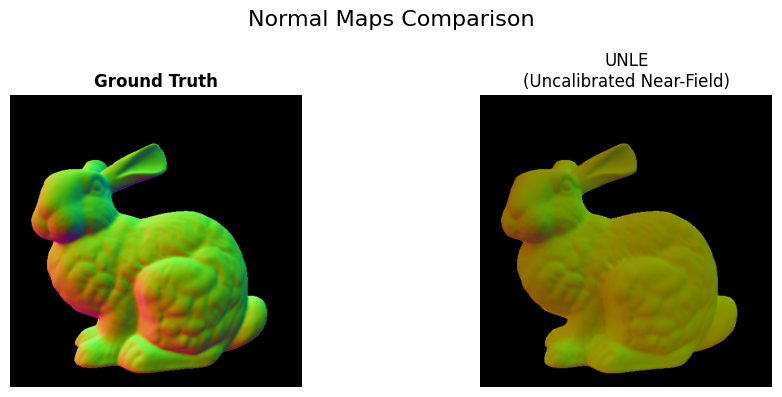

In [25]:
def visualize_normals(normals, mask=None):
    """Convert normals to RGB for visualization."""
    if mask is None:
        norms = np.linalg.norm(normals, axis=2)
        mask = (norms >= 0.5).astype(bool)

    vis_normals = (normals + 1.0) / 2.0
    vis_normals = np.clip(vis_normals, 0, 1)
    vis_normals[mask == 0] = 0
    return vis_normals

# Create mask for near-field methods
norms_gt = np.linalg.norm(gt_normals, axis=2)
valid_mask_gt = (norms_gt >= 0.5).astype(bool)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Normal Maps Comparison', fontsize=16)

# Ground truth
axes[0].imshow(visualize_normals(gt_normals, valid_mask_gt))
axes[0].set_title('Ground Truth', fontweight='bold')
axes[0].axis('off')

# Uncalibrated Near-Field (UNLE)
axes[1].imshow(visualize_normals(N_unle, engine.mask))
axes[1].set_title('UNLE\n(Uncalibrated Near-Field)')
axes[1].axis('off')

plt.tight_layout()
plt.show()


## 6. Visualize Results - Albedo

Compare estimated albedo from UNLE with ground truth.


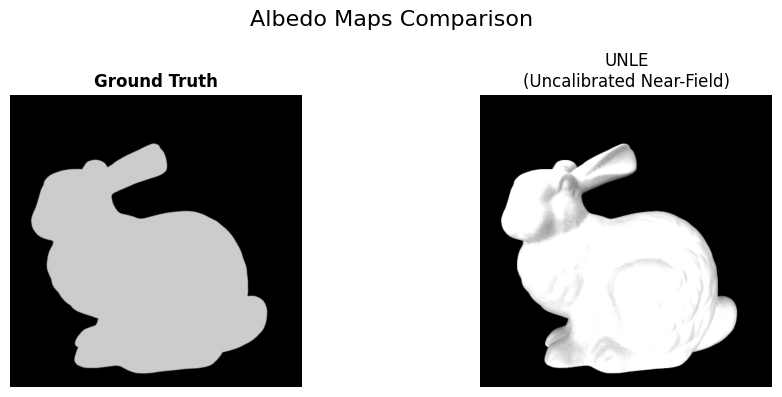

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Albedo Maps Comparison', fontsize=16)

# Ground truth
axes[0].imshow(gt_albedos, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Ground Truth', fontweight='bold')
axes[0].axis('off')

# Uncalibrated Near-Field (UNLE)
axes[1].imshow(A_unle, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('UNLE\n(Uncalibrated Near-Field)')
axes[1].axis('off')

plt.tight_layout()
plt.show()


## 7. Visualize Results - Depth

Compare estimated depth from UNLE with ground truth.


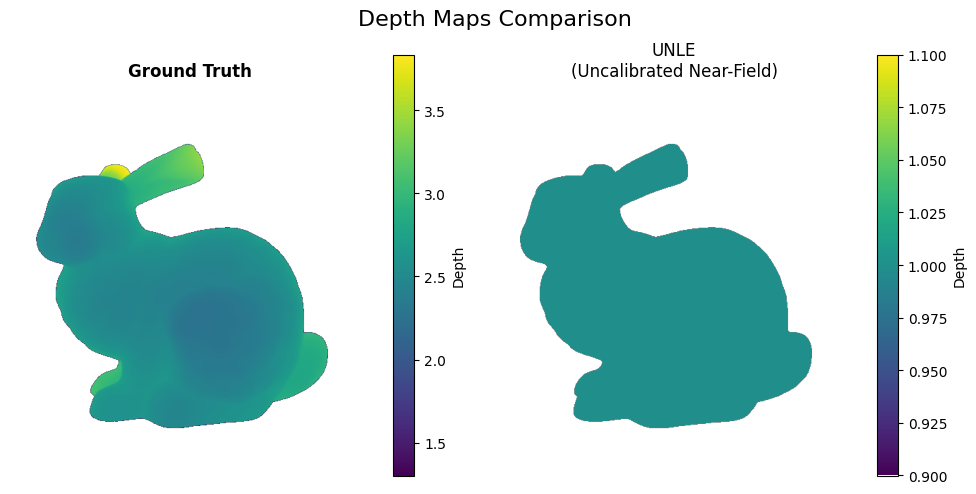

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Depth Maps Comparison', fontsize=16)

# Ground truth depth
z_gt_vis = gt_depth.copy()
z_gt_vis[~valid_mask_gt] = np.nan
im1 = axes[0].imshow(z_gt_vis, cmap='viridis')
axes[0].set_title('Ground Truth', fontweight='bold')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], label='Depth')

# UNLE depth
z_unle_vis = z_unle.copy()
z_unle_vis[~engine.mask] = np.nan
im2 = axes[1].imshow(z_unle_vis, cmap='viridis')
axes[1].set_title('UNLE\n(Uncalibrated Near-Field)')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], label='Depth')

plt.tight_layout()
plt.show()


## 8. Quantitative Evaluation

Compute error metrics for normals, albedo, depth, and light positions.


In [28]:
def compute_normal_error(normals_pred, normals_gt, mask=None):
    """Compute mean angular error in degrees."""
    if mask is None:
        norms_gt = np.linalg.norm(normals_gt, axis=2)
        mask = (norms_gt >= 0.5).astype(bool)
    
    # Flatten and filter by mask
    normals_pred_flat = normals_pred[mask]
    normals_gt_flat = normals_gt[mask]
    
    # Normalize
    normals_pred_flat = normals_pred_flat / (np.linalg.norm(normals_pred_flat, axis=1, keepdims=True) + 1e-6)
    normals_gt_flat = normals_gt_flat / (np.linalg.norm(normals_gt_flat, axis=1, keepdims=True) + 1e-6)
    
    # Compute dot product
    dot_product = np.sum(normals_pred_flat * normals_gt_flat, axis=1)
    dot_product = np.clip(dot_product, -1.0, 1.0)
    
    # Compute angular error
    angular_error = np.arccos(dot_product) * 180.0 / np.pi
    
    return np.mean(angular_error), np.median(angular_error)

def compute_albedo_error(albedo_pred, albedo_gt, mask=None):
    """Compute MSE and RMSE for albedo."""
    if mask is None:
        norms_gt = np.linalg.norm(gt_normals, axis=2)
        mask = (norms_gt >= 0.5).astype(bool)
    
    albedo_pred_flat = albedo_pred[mask]
    albedo_gt_flat = albedo_gt[mask]
    
    mse = np.mean((albedo_pred_flat - albedo_gt_flat) ** 2)
    rmse = np.sqrt(mse)
    
    return mse, rmse

def compute_depth_error(depth_pred, depth_gt, mask=None):
    """Compute RMSE for depth."""
    if mask is None:
        norms_gt = np.linalg.norm(gt_normals, axis=2)
        mask = (norms_gt >= 0.5).astype(bool)
    
    depth_pred_flat = depth_pred[mask]
    depth_gt_flat = depth_gt[mask]
    
    rmse = np.sqrt(np.mean((depth_pred_flat - depth_gt_flat) ** 2))
    
    return rmse

def compute_light_direction_error(L_pred, L_gt):
    """Compute Euclidean and angular error for light directions/positions."""
    # Euclidean error
    euclid_errors = np.linalg.norm(L_pred - L_gt, axis=1)
    mean_euclid = np.mean(euclid_errors)
    
    # Angular error (for directions)
    L_pred_norm = L_pred / (np.linalg.norm(L_pred, axis=1, keepdims=True) + 1e-8)
    L_gt_norm = L_gt / (np.linalg.norm(L_gt, axis=1, keepdims=True) + 1e-8)
    dot_products = np.sum(L_pred_norm * L_gt_norm, axis=1)
    dot_products = np.clip(dot_products, -1.0, 1.0)
    angular_errors = np.arccos(dot_products) * 180.0 / np.pi
    mean_angular = np.mean(angular_errors)
    
    return mean_euclid, mean_angular


In [42]:
# Compute errors for UNLE and LightNet
print("="*80)
print("QUANTITATIVE EVALUATION")
print("="*80)



# Uncalibrated Near-Field (UNF/UNLE)
unle_normal_mean, unle_normal_median = compute_normal_error(N_unle, gt_normals, engine.mask)
unle_albedo_mse, unle_albedo_rmse = compute_albedo_error(A_unle, gt_albedos, engine.mask)
unle_depth_rmse = compute_depth_error(z_unle, gt_depth, engine.mask)
unle_light_euclid, unle_light_angular = compute_light_direction_error(L_unle, gt_light_positions)

print("\nUncalibrated Near-Field (UNF/UNLE):")
print(f"  Normal Angular Error (Mean):   {unle_normal_mean:.2f}°")
print(f"  Normal Angular Error (Median): {unle_normal_median:.2f}°")
print(f"  Albedo MSE:                     {unle_albedo_mse:.4f}")
print(f"  Albedo RMSE:                    {unle_albedo_rmse:.4f}")
print(f"  Depth RMSE:                     {unle_depth_rmse:.4f}")
print(f"  Light Position Euclidean Err: {unle_light_euclid:.4f}")
print(f"  Light Position Angular Err:    {unle_light_angular:.2f}°")

# LightNet (ML-based)
lightnet_light_euclid, lightnet_light_angular = compute_light_direction_error(L_lightnet, gt_light_positions)

print("\nLightNet (ML-based Light Estimation):")
print(f"  Light Position Euclidean Err: {lightnet_light_euclid:.4f}")
print(f"  Light Position Angular Err:    {lightnet_light_angular:.2f}°")

print("\n" + "="*80)


QUANTITATIVE EVALUATION

Uncalibrated Near-Field (UNF/UNLE):
  Normal Angular Error (Mean):   28.95°
  Normal Angular Error (Median): 27.86°
  Albedo MSE:                     0.0704
  Albedo RMSE:                    0.2653
  Depth RMSE:                     1.5524
  Light Position Euclidean Err: 9.8648
  Light Position Angular Err:    128.66°

LightNet (ML-based Light Estimation):
  Light Position Euclidean Err: 12.1292
  Light Position Angular Err:    105.05°



## 9. Light Position Comparison

Compare estimated light positions from UNLE and LightNet with ground truth.


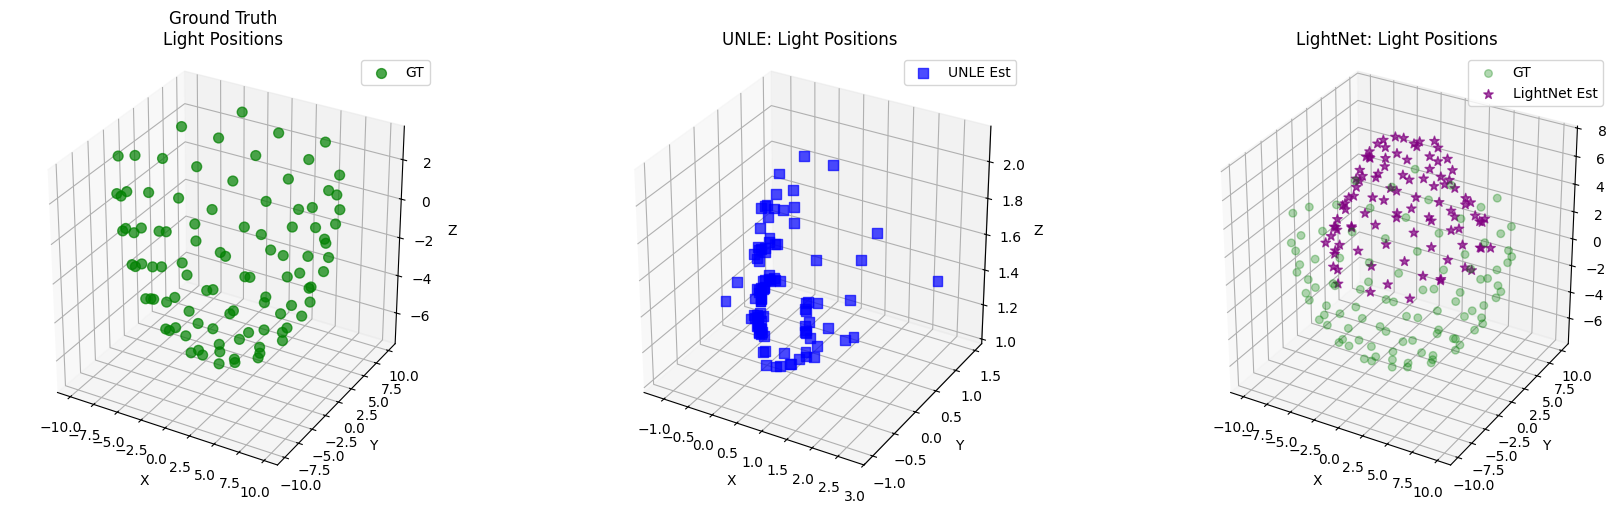

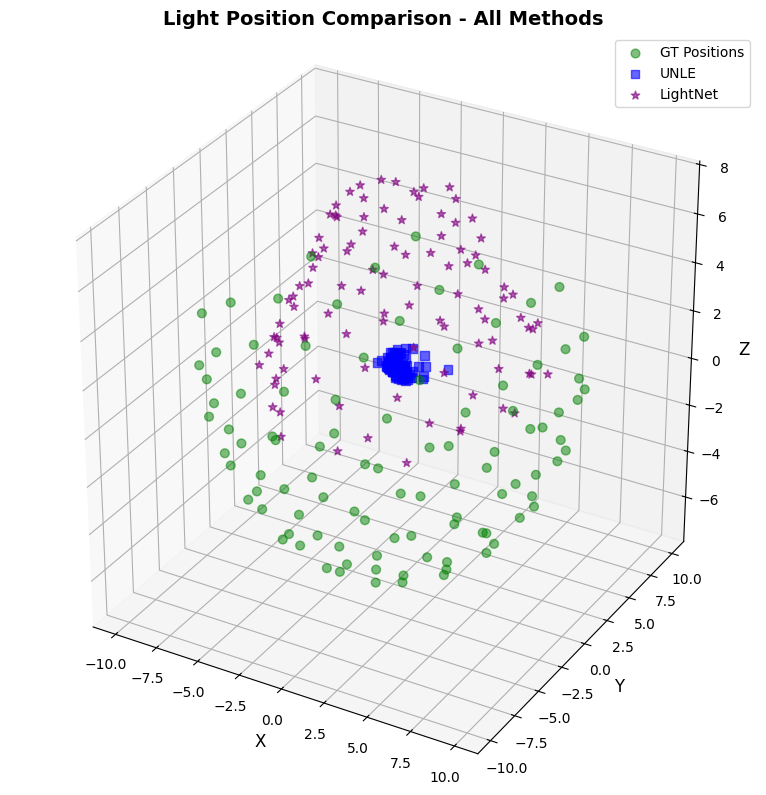

In [43]:
# Visualize light positions
fig = plt.figure(figsize=(18, 5))

# Ground truth light positions
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(gt_light_positions[:, 0], gt_light_positions[:, 1], gt_light_positions[:, 2], 
           c='green', marker='o', s=50, alpha=0.7, label='GT')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Ground Truth\nLight Positions')
ax1.legend()
ax1.set_box_aspect([1,1,1])

# Near-field: Light positions - UNLE
ax2 = fig.add_subplot(132, projection='3d')
# ax2.scatter(gt_light_positions[:, 0], gt_light_positions[:, 1], gt_light_positions[:, 2], 
#            c='green', marker='o', s=30, alpha=0.3, label='GT')
ax2.scatter(L_unle[:, 0], L_unle[:, 1], L_unle[:, 2], 
           c='blue', marker='s', s=50, alpha=0.7, label='UNLE Est')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('UNLE: Light Positions')
ax2.legend()
ax2.set_box_aspect([1,1,1])

# Near-field: Light positions - LightNet
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(gt_light_positions[:, 0], gt_light_positions[:, 1], gt_light_positions[:, 2], 
           c='green', marker='o', s=30, alpha=0.3, label='GT')
ax3.scatter(L_lightnet[:, 0], L_lightnet[:, 1], L_lightnet[:, 2], 
           c='purple', marker='*', s=50, alpha=0.7, label='LightNet Est')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.set_title('LightNet: Light Positions')
ax3.legend()
ax3.set_box_aspect([1,1,1])

plt.tight_layout()
plt.show()

# Combined comparison
fig2 = plt.figure(figsize=(10, 8))
ax_combined = fig2.add_subplot(111, projection='3d')
ax_combined.scatter(gt_light_positions[:, 0], gt_light_positions[:, 1], gt_light_positions[:, 2], 
           c='green', marker='o', s=40, alpha=0.5, label='GT Positions')
ax_combined.scatter(L_unle[:, 0], L_unle[:, 1], L_unle[:, 2], 
           c='blue', marker='s', s=40, alpha=0.6, label='UNLE')
ax_combined.scatter(L_lightnet[:, 0], L_lightnet[:, 1], L_lightnet[:, 2], 
           c='purple', marker='*', s=40, alpha=0.6, label='LightNet')
ax_combined.set_xlabel('X', fontsize=12)
ax_combined.set_ylabel('Y', fontsize=12)
ax_combined.set_zlabel('Z', fontsize=12)
ax_combined.set_title('Light Position Comparison - All Methods', fontsize=14, fontweight='bold')
ax_combined.legend(fontsize=10)
ax_combined.set_box_aspect([1,1,1])

plt.tight_layout()
plt.show()


## 10. Summary Table

Create a summary table comparing UNLE and LightNet methods.


In [22]:
import pandas as pd

# Create summary dataframe
summary_data = []

# UNLE
summary_data.append({
    "Method": "UNF/UNLE (Uncalibrated Near-Field)",
    "Normal Angular Error (°)": f"{unle_normal_mean:.2f}",
    "Albedo MSE": f"{unle_albedo_mse:.4f}",
    "Albedo RMSE": f"{unle_albedo_rmse:.4f}",
    "Depth RMSE": f"{unle_depth_rmse:.4f}",
    "Light Euclidean Error": f"{unle_light_euclid:.4f}",
    "Light Angular Error (°)": f"{unle_light_angular:.2f}"
})

# LightNet
summary_data.append({
    "Method": "LightNet (ML-based)",
    "Normal Angular Error (°)": "N/A (uses UNLE)",
    "Albedo MSE": "N/A (uses UNLE)",
    "Albedo RMSE": "N/A (uses UNLE)",
    "Depth RMSE": "N/A (uses UNLE)",
    "Light Euclidean Error": f"{lightnet_light_euclid:.4f}",
    "Light Angular Error (°)": f"{lightnet_light_angular:.2f}"
})

df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("SUMMARY TABLE - UNLE and LightNet Comparison")
print("="*80)
print(df.to_string(index=False))
print("="*80)


NameError: name 'lightnet_light_euclid' is not defined